In [8]:
from pyvis.network import Network
import networkx as nx
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
# lendo a matriz de correlação
cm = pd.read_parquet('data/processed/corr_matrix.parquet')

In [7]:
tickers = cm.columns.tolist()
len(tickers)

920

In [9]:
# criando o grafo utilizando networkx e como a matriz de correlação é simetrica, ou seja
# corr(A, B) = corr(B, A), podemos criar o grafo com apenas a triangular superior da matriz

# Criar grafo a partir da matriz de correlação
G = nx.Graph()

for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        corr = cm.iloc[i, j]
        if np.isfinite(corr) and abs(corr):
            G.add_edge(tickers[i], tickers[j], weight=round(corr, 4))

nx.write_graphml(G, "correlacao_b3.graphml")

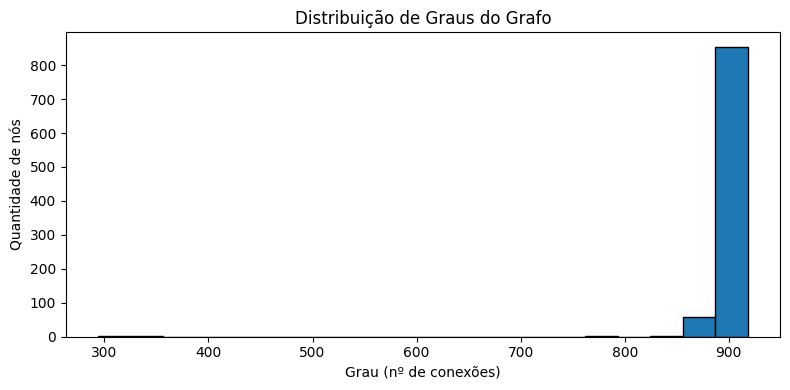

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.read_graphml("correlacao_b3.graphml")

degrees = [d for _, d in G.degree()]

plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=20, edgecolor='black')
plt.xlabel("Grau (nº de conexões)")
plt.ylabel("Quantidade de nós")
plt.title("Distribuição de Graus do Grafo")
plt.tight_layout()
plt.show()

In [3]:
n = G.number_of_nodes()
e = G.number_of_edges()
grau_medio = (2 * e) / n

print(f"Vértices: {n}")
print(f"Arestas: {e}")
print(f"Grau médio: {grau_medio:.1f}")

Vértices: 919
Arestas: 418757
Grau médio: 911.3
